In [1]:
import pandas as pd
df = pd.read_csv('e_commerce_store.csv')

In [2]:
df.describe()

,Sales,Profit,Units Sold,Discount (%),Customer Rating
count,698.000000,698.000000,698.000000,698.000000,698.000000
mean,7358.320559,2488.094527,226.717765,12.757794,3.663438
std,3094.972508,1004.723565,98.300869,6.818527,0.651065
min,1254.220000,401.080000,50.000000,1.010000,1.860000
25%,4966.182500,1717.845000,148.000000,6.580000,3.212500
50%,7355.240000,2458.860000,225.000000,12.910000,3.650000
75%,9862.620000,3289.300000,307.000000,18.790000,4.150000
max,13641.030000,4455.560000,399.000000,24.890000,5.000000


Shapiro-Wilk Test Statistic: 0.9688684189602759
Shapiro-Wilk p-value: 5.053344482108816e-11
Data is not normally distributed (reject H0)


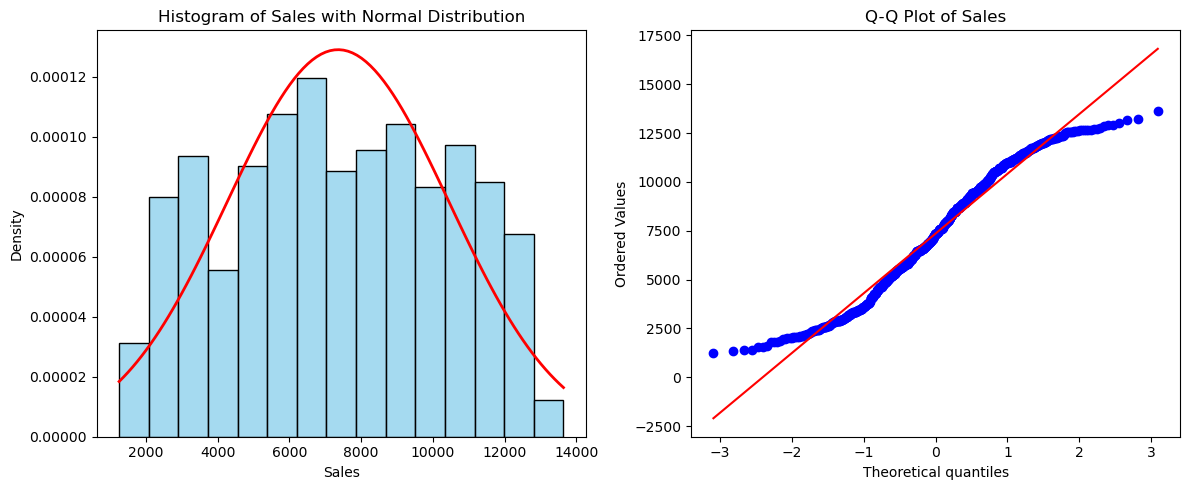

In [3]:
##NORMALITY CODE

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Assuming your dataframe is df
sales = df['Sales']

# ----------------------------
# 1. Shapiro-Wilk Test
# ----------------------------
shapiro_test = stats.shapiro(sales)
print('Shapiro-Wilk Test Statistic:', shapiro_test[0])
print('Shapiro-Wilk p-value:', shapiro_test[1])
if shapiro_test[1] > 0.05:
	print("Data seems normally distributed (fail to reject H0)")
else:
	print("Data is not normally distributed (reject H0)")

# ----------------------------
# 2. Histogram with Bell Curve
# ----------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(sales, kde=False, stat="density", bins=15, color='skyblue', edgecolor='black')
mu, std = stats.norm.fit(sales)
xmin, xmax = sales.min(), sales.max()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'r', linewidth=2)
plt.title('Histogram of Sales with Normal Distribution')
plt.xlabel('Sales')
plt.ylabel('Density')

# ----------------------------
# 3. Q-Q Plot
# ----------------------------
plt.subplot(1,2,2)
stats.probplot(sales, dist="norm", plot=plt)
plt.title('Q-Q Plot of Sales')

plt.tight_layout()
plt.show()


=== Profit ===
Shapiro-Wilk Test: stat=0.9740, p=0.0000 -> Not Normal


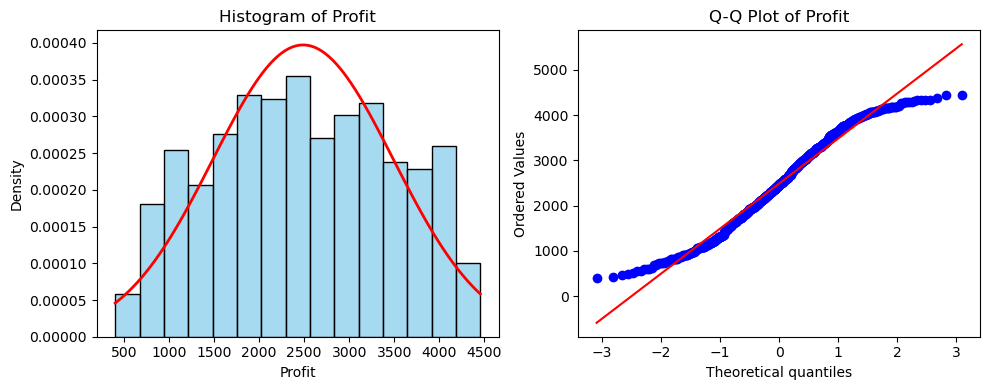


=== Units Sold ===
Shapiro-Wilk Test: stat=0.9636, p=0.0000 -> Not Normal


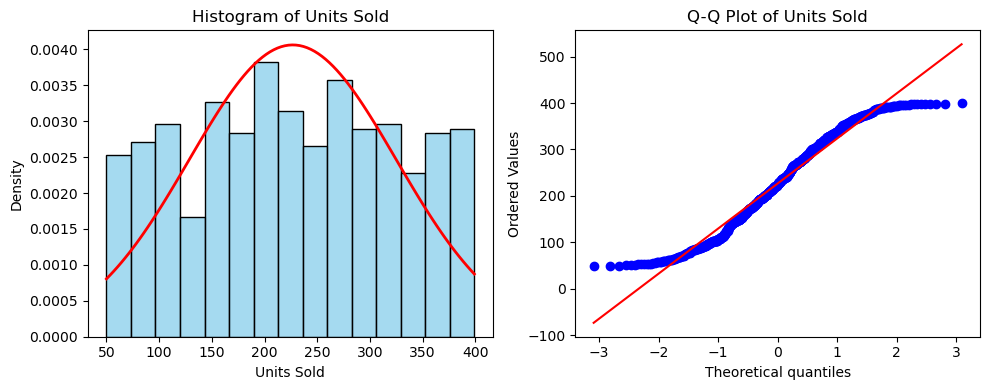


=== Discount (%) ===
Shapiro-Wilk Test: stat=0.9556, p=0.0000 -> Not Normal


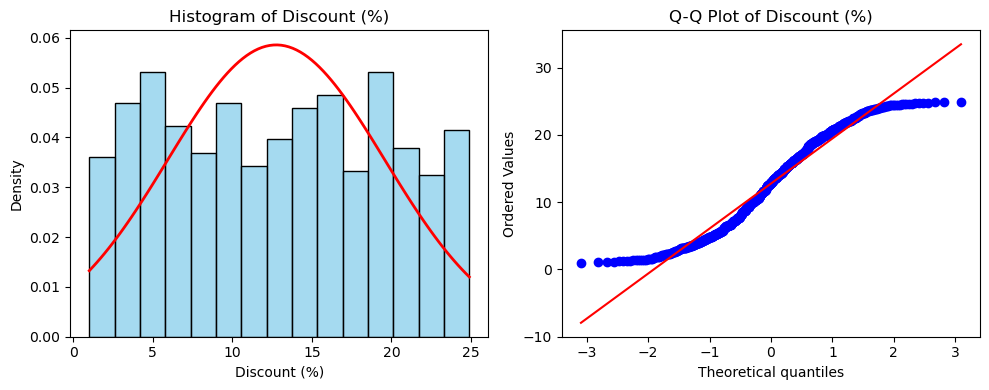


=== Customer Rating ===
Shapiro-Wilk Test: stat=0.9923, p=0.0011 -> Not Normal


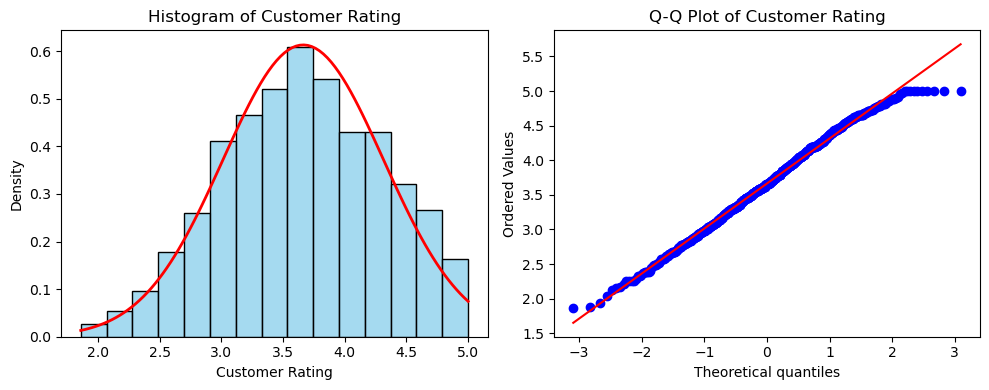

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# List of other numeric variables (excluding 'Sales')
other_vars = ['Profit', 'Units Sold', 'Discount (%)', 'Customer Rating']

for col in other_vars:
	data = df[col]
	print(f"\n=== {col} ===")
    
	# 1. Shapiro-Wilk Test
	stat, p = stats.shapiro(data)
	print(f"Shapiro-Wilk Test: stat={stat:.4f}, p={p:.4f} ->", "Normal" if p>0.05 else "Not Normal")
    
	# 2 & 3. Histogram with bell curve + Q-Q plot
	plt.figure(figsize=(10,4))
    
	# Histogram + Bell Curve
	plt.subplot(1,2,1)
	sns.histplot(data, kde=False, stat="density", bins=15, color='skyblue', edgecolor='black')
	x = np.linspace(data.min(), data.max(), 100)
	mu, std = np.mean(data), np.std(data)
	plt.plot(x, stats.norm.pdf(x, mu, std), 'r', linewidth=2)
	plt.title(f'Histogram of {col}')
    
	# Q-Q Plot
	plt.subplot(1,2,2)
	stats.probplot(data, dist="norm", plot=plt)
	plt.title(f'Q-Q Plot of {col}')
    
	plt.tight_layout()
	plt.show()

In [5]:
# List of other numeric variables
other_vars = ['Sales', 'Profit', 'Units Sold', 'Discount (%)', 'Customer Rating']

for col in other_vars:
	log_col = col + '_log'
	df[log_col] = np.log(df[col] + 1e-6)  # log transform
	stat, p = stats.shapiro(df[log_col])
	print(f"{log_col} Shapiro-Wilk Test: stat={stat:.4f}, p={p:.4f} ->", "Normal" if p>0.05 else "Not Normal")

Sales_log Shapiro-Wilk Test: stat=0.9289, p=0.0000 -> Not Normal
Profit_log Shapiro-Wilk Test: stat=0.9346, p=0.0000 -> Not Normal
Units Sold_log Shapiro-Wilk Test: stat=0.9240, p=0.0000 -> Not Normal
Discount (%)_log Shapiro-Wilk Test: stat=0.9029, p=0.0000 -> Not Normal
Customer Rating_log Shapiro-Wilk Test: stat=0.9764, p=0.0000 -> Not Normal


In [7]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

# List of variables for correlation analysis
vars_list = ['Sales', 'Profit', 'Units Sold', 'Discount (%)', 'Customer Rating']

# Initialize empty DataFrames
corr_matrix = pd.DataFrame(index=vars_list, columns=vars_list)
pval_matrix = pd.DataFrame(index=vars_list, columns=vars_list)

# Compute correlation and p-values
for i in vars_list:
    for j in vars_list:
        corr, pval = pearsonr(df[i], df[j])
        corr_matrix.loc[i, j] = corr
        pval_matrix.loc[i, j] = pval

# Convert to numeric
corr_matrix = corr_matrix.astype(float)
pval_matrix = pval_matrix.astype(float)

print("Correlation Matrix:\n", corr_matrix)
print("\nP-value Matrix:\n", pval_matrix)

Correlation Matrix:
                     Sales    Profit  Units Sold  Discount (%)  Customer Rating
Sales            1.000000  0.988224    0.993970     -0.027220         0.780351
Profit           0.988224  1.000000    0.985183     -0.018570         0.777644
Units Sold       0.993970  0.985183    1.000000      0.011339         0.763307
Discount (%)    -0.027220 -0.018570    0.011339      1.000000        -0.046270
Customer Rating  0.780351  0.777644    0.763307     -0.046270         1.000000

P-value Matrix:
                          Sales         Profit     Units Sold  Discount (%)  \
Sales             0.000000e+00   0.000000e+00   0.000000e+00      0.472757   
Profit            0.000000e+00   0.000000e+00   0.000000e+00      0.624284   
Units Sold        0.000000e+00   0.000000e+00   0.000000e+00      0.764910   
Discount (%)      4.727572e-01   6.242836e-01   7.649098e-01      0.000000   
Customer Rating  4.848168e-144  2.033779e-142  3.435478e-134      0.222124   

                 C

In [8]:
import pandas as pd
import statsmodels.api as sm

# Predictor variables (exclude 'Profit')
X = df[['Sales', 'Units Sold', 'Discount (%)', 'Customer Rating']]

# Add constant term for intercept
X = sm.add_constant(X)

# Dependent variable
y = df['Profit']

# Fit linear regression model
model = sm.OLS(y, X).fit()

# Summary of regression
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Profit   R-squared:                       0.978
Model:                            OLS   Adj. R-squared:                  0.977
Method:                 Least Squares   F-statistic:                     7538.
Date:                Thu, 01 Oct 2026   Prob (F-statistic):               0.00
Time:                        17:56:22   Log-Likelihood:                -4490.1
No. Observations:                 698   AIC:                             8990.
Df Residuals:                     693   BIC:                             9013.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              50.9560     39.557     

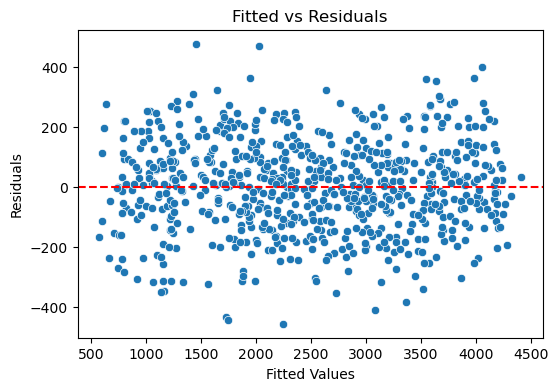

Shapiro-Wilk Test for Residuals: stat=0.9981, p=0.6162 -> Normal


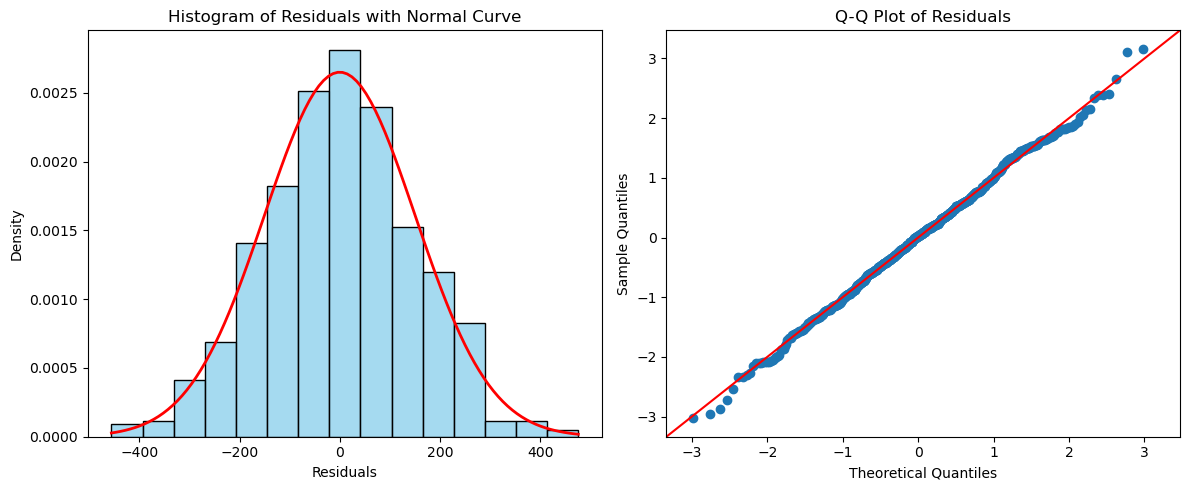

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm

# Assuming 'model' is your fitted OLS model
residuals = model.resid
fitted = model.fittedvalues

# 1. Fitted vs Residual plot
plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Fitted vs Residuals')
plt.show()

# 2. Shapiro-Wilk test for residuals
stat, p = stats.shapiro(residuals)
print(f"Shapiro-Wilk Test for Residuals: stat={stat:.4f}, p={p:.4f} ->", "Normal" if p>0.05 else "Not Normal")

# 3 & 4. Histogram with bell curve + Q-Q plot
plt.figure(figsize=(12,5))

# Histogram with bell curve
plt.subplot(1,2,1)
sns.histplot(residuals, kde=False, stat='density', bins=15, color='skyblue', edgecolor='black')
mu, std = np.mean(residuals), np.std(residuals)
x = np.linspace(residuals.min(), residuals.max(), 100)
plt.plot(x, stats.norm.pdf(x, mu, std), 'r', linewidth=2)
plt.title('Histogram of Residuals with Normal Curve')
plt.xlabel('Residuals')
plt.ylabel('Density')

# Q-Q plot
plt.subplot(1,2,2)
sm.qqplot(residuals, line='45', fit=True, ax=plt.gca())
plt.title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

In [10]:
import pandas as pd
import statsmodels.api as sm

# Predictor variables (exclude 'Profit')
X = df[['Sales_log', 'Units Sold_log', 'Discount (%)_log', 'Customer Rating_log']]

# Add constant term for intercept
X = sm.add_constant(X)

# Dependent variable
y = df['Profit_log']

# Fit linear regression model
model = sm.OLS(y, X).fit()

# Summary of regression
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Profit_log   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.965
Method:                 Least Squares   F-statistic:                     4810.
Date:                Thu, 01 Oct 2026   Prob (F-statistic):               0.00
Time:                        18:03:31   Log-Likelihood:                 690.65
No. Observations:                 698   AIC:                            -1371.
Df Residuals:                     693   BIC:                            -1349.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.1483    

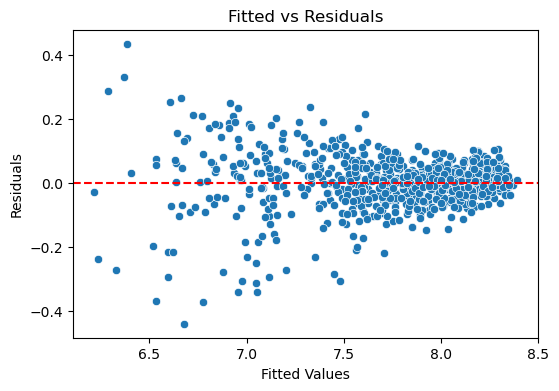

Shapiro-Wilk Test for Residuals: stat=0.9297, p=0.0000 -> Not Normal


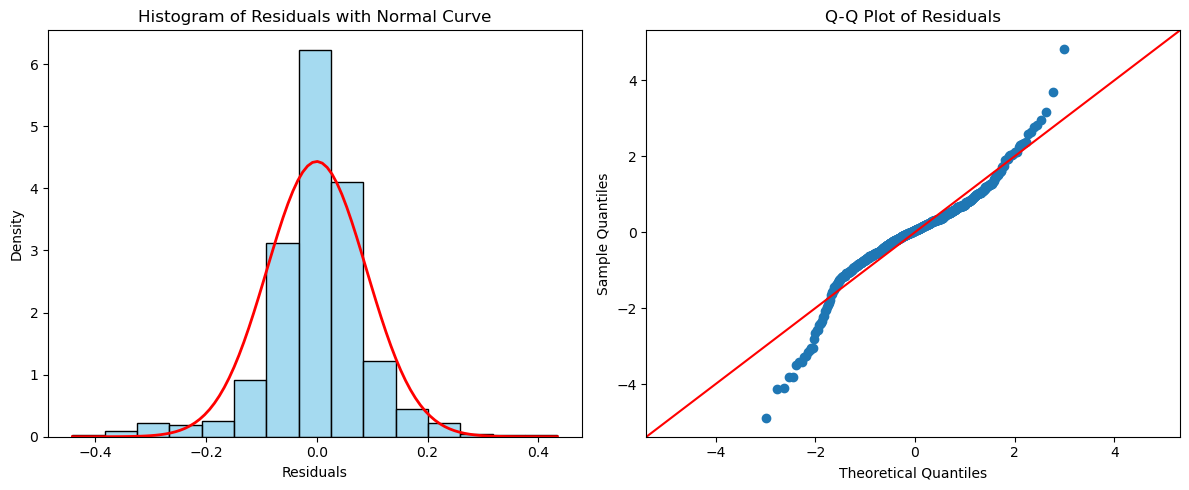

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm

# Assuming 'model' is your fitted OLS model
residuals = model.resid
fitted = model.fittedvalues

# 1. Fitted vs Residual plot
plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Fitted vs Residuals')
plt.show()

# 2. Shapiro-Wilk test for residuals
stat, p = stats.shapiro(residuals)
print(f"Shapiro-Wilk Test for Residuals: stat={stat:.4f}, p={p:.4f} ->", "Normal" if p>0.05 else "Not Normal")

# 3 & 4. Histogram with bell curve + Q-Q plot
plt.figure(figsize=(12,5))

# Histogram with bell curve
plt.subplot(1,2,1)
sns.histplot(residuals, kde=False, stat='density', bins=15, color='skyblue', edgecolor='black')
mu, std = np.mean(residuals), np.std(residuals)
x = np.linspace(residuals.min(), residuals.max(), 100)
plt.plot(x, stats.norm.pdf(x, mu, std), 'r', linewidth=2)
plt.title('Histogram of Residuals with Normal Curve')
plt.xlabel('Residuals')
plt.ylabel('Density')

# Q-Q plot
plt.subplot(1,2,2)
sm.qqplot(residuals, line='45', fit=True, ax=plt.gca())
plt.title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()